In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import train_test_split_edges, negative_sampling
from torch_geometric.transforms import NormalizeFeatures
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Koristimo:", device)

Koristimo: cpu


In [6]:
dataset = Planetoid(root='./data', name='Cora', transform=NormalizeFeatures())
data = dataset[0]
data = train_test_split_edges(data)

data = data.to(device)

all_pos_edge_index = torch.cat(
    [data.train_pos_edge_index, data.val_pos_edge_index, data.test_pos_edge_index],
    dim=1,
)

print("Trening grane:    ", data.train_pos_edge_index.shape[1])
print("Validacione grane:", data.val_pos_edge_index.shape[1])
print("Test grane:       ", data.test_pos_edge_index.shape[1])

Trening grane:     8976
Validacione grane: 263
Test grane:        527


/tmp/ipykernel_52452/90601031.py:3: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  data = train_test_split_edges(data)


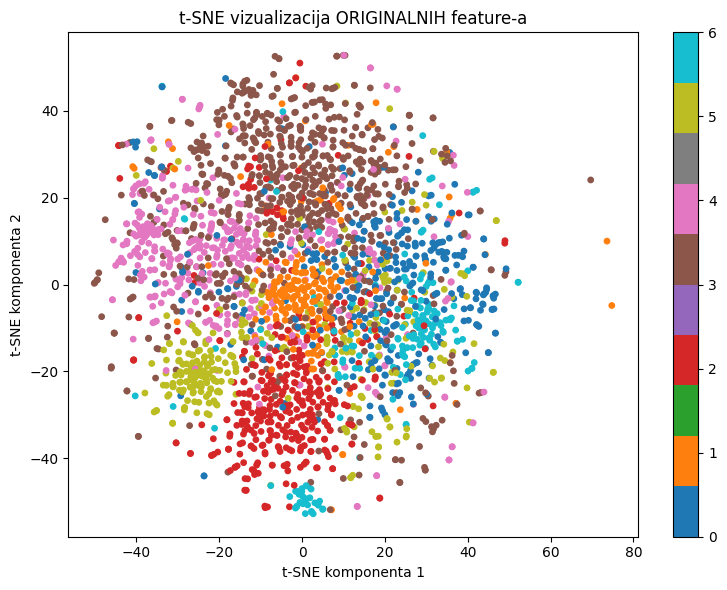

In [7]:

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

x_2d = tsne.fit_transform(data.x.cpu().numpy())

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    x_2d[:, 0],
    x_2d[:, 1],
    c=data.y.cpu().numpy(),
    cmap='tab10',
    s=15
)

plt.colorbar(scatter)
plt.title("t-SNE vizualizacija ORIGINALNIH feature-a")
plt.xlabel("t-SNE komponenta 1")
plt.ylabel("t-SNE komponenta 2")

plt.tight_layout()
plt.savefig('../results/gae_tSne_feature.png', dpi=150)
plt.show()

In [8]:
from torch_geometric.nn import GCNConv

class GAE(nn.Module):
    def __init__(self, in_channels, hid_channels, out_channels):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hid_channels)
        self.conv2 = GCNConv(hid_channels, out_channels)

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)

        return x

    def decode(self, z, edge_label_index):
        return(z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim = -1)

    def decode_all(self, z):
        prob_adj = z @ z.t()

        prob_adj = prob_adj.sigmoid()

        return (prob_adj > 0.97).nonzero(as_tuple=False).t()

In [9]:
input_channels = dataset.num_features
hidden_channels = 64
output_channels = 32

model = GAE(
    in_channels=input_channels,
    hid_channels=hidden_channels,
    out_channels=output_channels
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

In [10]:
def train():
    model.train()
    optimizer.zero_grad()
    
    z = model.encode(data.x, data.train_pos_edge_index)
    
    neg_edge_index = negative_sampling(
        edge_index=all_pos_edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=data.train_pos_edge_index.shape[1]
    )
    
    edge_index = torch.cat([data.train_pos_edge_index, neg_edge_index], dim=1)
    
    labels = torch.cat([
        torch.ones(data.train_pos_edge_index.shape[1]),
        torch.zeros(neg_edge_index.shape[1])
    ]).to(device)
    
    out = model.decode(z, edge_index)
    
    loss = criterion(out, labels)
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [11]:
@torch.no_grad()
def evaluate(pos_edge_index, neg_edge_index):
    model.eval()
    z = model.encode(data.x, data.train_pos_edge_index)
    
    edge_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
    
    out = model.decode(z, edge_index).sigmoid().cpu().numpy()
    
    labels = torch.cat([
        torch.ones(pos_edge_index.shape[1]),
        torch.zeros(neg_edge_index.shape[1])
    ]).numpy()
    
    auc = roc_auc_score(labels, out)
    ap  = average_precision_score(labels, out)
    return auc, ap

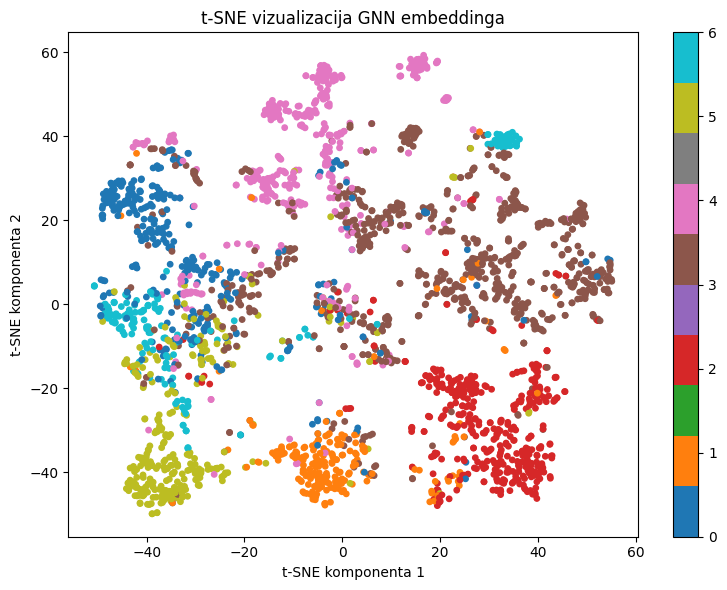

In [14]:

model.eval()

with torch.no_grad():
    z = model.encode(data.x, data.train_pos_edge_index)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

z_2d = tsne.fit_transform(z.cpu().numpy())

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    z_2d[:, 0],
    z_2d[:, 1],
    c=data.y.cpu().numpy(),
    cmap='tab10',
    s=15
)

plt.colorbar(scatter)
plt.title("t-SNE vizualizacija GNN embeddinga")
plt.xlabel("t-SNE komponenta 1")
plt.ylabel("t-SNE komponenta 2")

plt.tight_layout()
plt.savefig('../results/gae_tSne_embedding.png', dpi=150)
plt.show()

In [13]:
val_neg  = negative_sampling(all_pos_edge_index, data.num_nodes, data.val_pos_edge_index.shape[1])
test_neg = negative_sampling(all_pos_edge_index, data.num_nodes, data.test_pos_edge_index.shape[1])

train_losses = []
val_aucs     = []
val_aps      = []


best_val_auc = 0
for epoch in range(1, 201):
    loss = train()

    train_losses.append(loss)
    
    if epoch % 10 == 0:
        val_auc, val_ap = evaluate(data.val_pos_edge_index, val_neg)
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")

        val_aucs.append(val_auc)
        val_aps.append(val_ap)
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), 'best_gae_model.pt')

model.load_state_dict(torch.load('best_gae_model.pt'))
test_auc, test_ap = evaluate(data.test_pos_edge_index, test_neg)
print(f"\n=== FINALNI REZULTATI ===")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test AP:  {test_ap:.4f}")

Epoch 010 | Loss: 0.6662 | Val AUC: 0.7358 | Val AP: 0.7765
Epoch 020 | Loss: 0.6058 | Val AUC: 0.7877 | Val AP: 0.8053
Epoch 030 | Loss: 0.5181 | Val AUC: 0.8046 | Val AP: 0.8117
Epoch 040 | Loss: 0.4841 | Val AUC: 0.8596 | Val AP: 0.8645
Epoch 050 | Loss: 0.4688 | Val AUC: 0.8764 | Val AP: 0.8835
Epoch 060 | Loss: 0.4635 | Val AUC: 0.8783 | Val AP: 0.8851
Epoch 070 | Loss: 0.4555 | Val AUC: 0.8871 | Val AP: 0.8928
Epoch 080 | Loss: 0.4467 | Val AUC: 0.8905 | Val AP: 0.8923
Epoch 090 | Loss: 0.4428 | Val AUC: 0.8940 | Val AP: 0.8942
Epoch 100 | Loss: 0.4397 | Val AUC: 0.9003 | Val AP: 0.9035
Epoch 110 | Loss: 0.4426 | Val AUC: 0.9037 | Val AP: 0.9067
Epoch 120 | Loss: 0.4388 | Val AUC: 0.9007 | Val AP: 0.9047
Epoch 130 | Loss: 0.4360 | Val AUC: 0.9046 | Val AP: 0.9091
Epoch 140 | Loss: 0.4335 | Val AUC: 0.9089 | Val AP: 0.9146
Epoch 150 | Loss: 0.4273 | Val AUC: 0.9100 | Val AP: 0.9167
Epoch 160 | Loss: 0.4220 | Val AUC: 0.9103 | Val AP: 0.9176
Epoch 170 | Loss: 0.4241 | Val AUC: 0.91

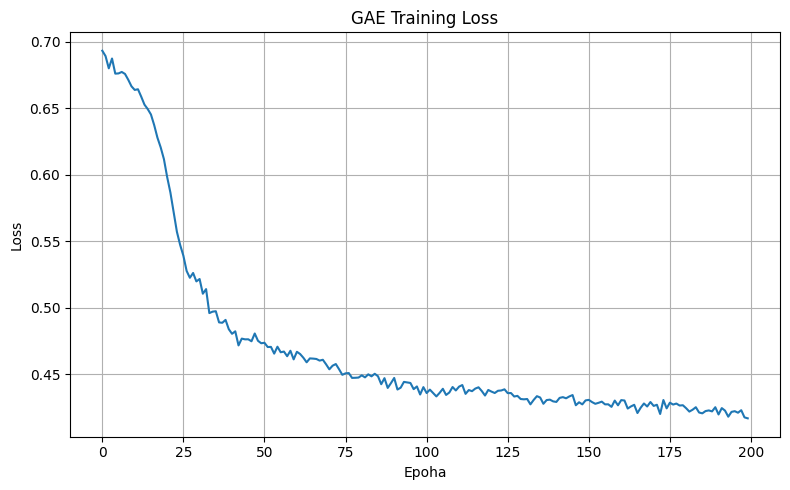

In [10]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.title("GAE Training Loss")

plt.grid(True)
plt.tight_layout()

plt.savefig("../results/gae_loss_curve.png", dpi=300)

plt.show()

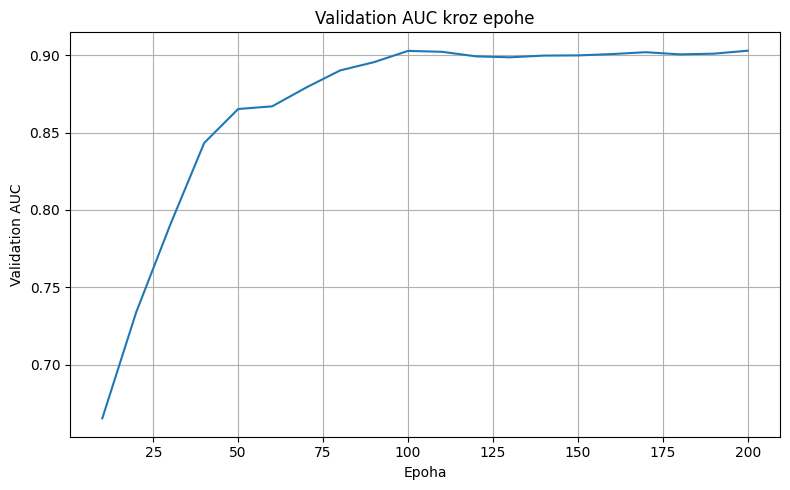

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    range(10, 201, 10),
    val_aucs
)

plt.xlabel("Epoha")
plt.ylabel("Validation AUC")
plt.title("Validation AUC kroz epohe")

plt.grid(True)
plt.tight_layout()

plt.savefig("../results/gae_auc_curve.png", dpi=300)

plt.show()

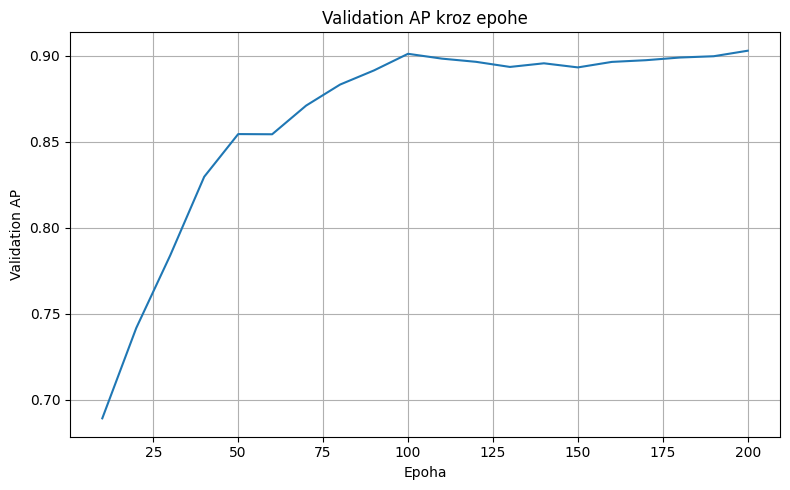

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    range(10, 201, 10),
    val_aps
)

plt.xlabel("Epoha")
plt.ylabel("Validation AP")
plt.title("Validation AP kroz epohe")

plt.grid(True)
plt.tight_layout()

plt.savefig("../results/gae_ap_curve.png", dpi=300)

plt.show()

In [13]:

configs = [
    {"hidden": 64,  "out": 32, "lr": 0.01,  "epochs": 200},
    {"hidden": 128, "out": 64, "lr": 0.01,  "epochs": 200},
    {"hidden": 32,  "out": 16, "lr": 0.01,  "epochs": 200},
    {"hidden": 64,  "out": 32, "lr": 0.001, "epochs": 300},
]

results = []

for cfg in configs:
    torch.manual_seed(42)
    model_exp = GAE(
        in_channels=input_channels,
        hid_channels=cfg["hidden"],
        out_channels=cfg["out"]
    ).to(device)
    optimizer_exp = torch.optim.Adam(model_exp.parameters(), lr=cfg["lr"])

    for epoch in range(1, cfg["epochs"] + 1):
        model_exp.train()
        optimizer_exp.zero_grad()
        z = model_exp.encode(data.x, data.train_pos_edge_index)
        neg_edge_index = negative_sampling(
            edge_index=all_pos_edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=data.train_pos_edge_index.shape[1]
        )
        edge_index = torch.cat([data.train_pos_edge_index, neg_edge_index], dim=1)
        labels = torch.cat([
            torch.ones(data.train_pos_edge_index.shape[1]),
            torch.zeros(neg_edge_index.shape[1])
        ]).to(device)
        out = model_exp.decode(z, edge_index)
        loss = criterion(out, labels)
        loss.backward()
        optimizer_exp.step()

    @torch.no_grad()
    def eval_exp(m, pos_ei, neg_ei):
        m.eval()
        z = m.encode(data.x, data.train_pos_edge_index)
        ei = torch.cat([pos_ei, neg_ei], dim=1)
        out = m.decode(z, ei).sigmoid().cpu().numpy()
        lbl = torch.cat([
            torch.ones(pos_ei.shape[1]),
            torch.zeros(neg_ei.shape[1])
        ]).numpy()
        return roc_auc_score(lbl, out), average_precision_score(lbl, out)

    test_auc, test_ap = eval_exp(model_exp, data.test_pos_edge_index, test_neg)
    results.append({
        "hidden": cfg["hidden"],
        "out": cfg["out"],
        "lr": cfg["lr"],
        "epochs": cfg["epochs"],
        "Test AUC": round(test_auc, 4),
        "Test AP":  round(test_ap, 4)
    })
    print(f"hidden={cfg['hidden']:3d}, out={cfg['out']:2d}, lr={cfg['lr']} → AUC={test_auc:.4f}, AP={test_ap:.4f}")

hidden= 64, out=32, lr=0.01 → AUC=0.8970, AP=0.9002
hidden=128, out=64, lr=0.01 → AUC=0.9073, AP=0.9159
hidden= 32, out=16, lr=0.01 → AUC=0.8933, AP=0.8990
hidden= 64, out=32, lr=0.001 → AUC=0.8323, AP=0.8347


In [14]:
import pandas as pd

df = pd.DataFrame(results)
df = df.sort_values("Test AUC", ascending=False).reset_index(drop=True)
display(df)

,hidden,out,lr,epochs,Test AUC,Test AP
0,128,64,0.010,200,0.9073,0.9159
1,64,32,0.010,200,0.8970,0.9002
2,32,16,0.010,200,0.8933,0.8990
3,64,32,0.001,300,0.8323,0.8347


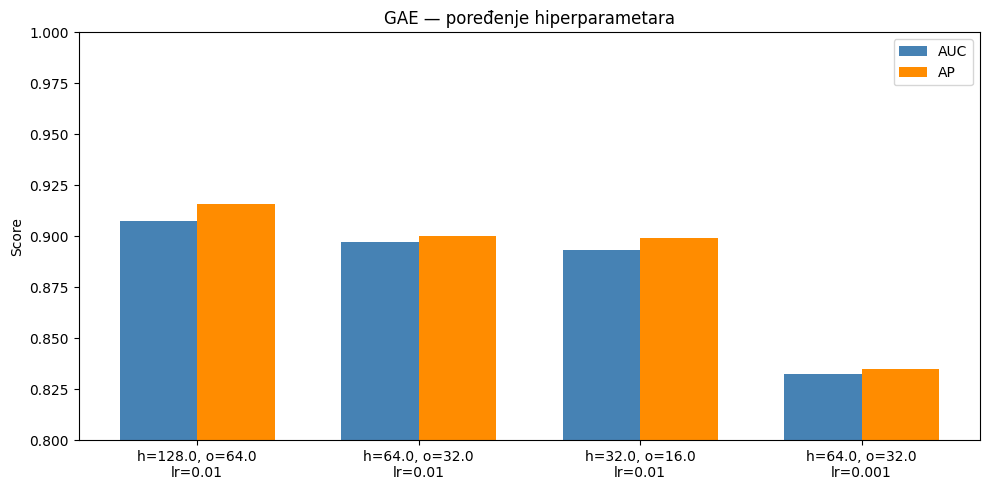

In [15]:
import matplotlib.pyplot as plt

labels_cfg = [f"h={r['hidden']}, o={r['out']}\nlr={r['lr']}" for _, r in df.iterrows()]
auc_vals   = df["Test AUC"].tolist()
ap_vals    = df["Test AP"].tolist()

x = range(len(labels_cfg))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], auc_vals, width, label='AUC', color='steelblue')
ax.bar([i + width/2 for i in x], ap_vals,  width, label='AP',  color='darkorange')

ax.set_ylabel("Score")
ax.set_title("GAE — poređenje hiperparametara")
ax.set_xticks(list(x))
ax.set_xticklabels(labels_cfg)
ax.set_ylim(0.8, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig('../results/gae_hyperparams.png', dpi=150)
plt.show()